## DSC 540 - Group Project - Diabetes Dataset

Team: 
John Leniart,
Kevin Trivino,
Rajan Bastakoti,
Adam Zizi,
Faizan Wali

## Introduction

Our group decided to work with a diabetes dataset that was published on Kaggle.

Link: https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset

The dataset contains data from the Behavioral Risk Factor Surveillance System (BRFSS). The BRFSS is a health-related telephone survey that is collected annually by the CDC. Each year, the survey collects responses from over 400,000 Americans on health-related risk behaviors, chronic health conditions, and the use of preventative services. The survey has been conducted every year since 1984.

The dataset we used (diabetes _ binary _ 5050split _ health _ indicators _ BRFSS2015.csv) is a clean dataset of 70,692 survey responses to the CDC's BRFSS 2015 survey. It has an equal 50-50 split of respondents with no diabetes and respondents with either prediabetes or diabetes. The target variable Diabetes_binary has 2 classes. 0 is for no diabetes, and 1 is for prediabetes or diabetes. This dataset has 21 feature variables and is balanced.

We initially started our analysis with the larger unbalanced dataset. However, our classification models were overfitting to the class 0 observations, which made up the vast majority of the dataset. Because of this, we made the decision to use the balanced "5050" dataset in an attempt to develop more well-rounded classification models.

------------------------------

## Exploratory Analysis

In [1]:
#loading packages
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#Load the data
#In this first file, the target variable has binary values (two classes)
diabetes_df = pd.read_csv("diabetes_binary_5050split_health_indicators_BRFSS2015.csv")

In [3]:
diabetes_df.head(10)

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0
5,0.0,0.0,0.0,1.0,18.0,0.0,0.0,0.0,1.0,1.0,...,0.0,0.0,2.0,7.0,0.0,0.0,0.0,1.0,4.0,7.0
6,0.0,0.0,1.0,1.0,26.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,13.0,5.0,6.0
7,0.0,0.0,0.0,1.0,31.0,1.0,0.0,0.0,0.0,1.0,...,1.0,0.0,4.0,0.0,0.0,0.0,1.0,6.0,4.0,3.0
8,0.0,0.0,0.0,1.0,32.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,0.0,3.0,6.0,8.0
9,0.0,0.0,0.0,1.0,27.0,1.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,6.0,0.0,1.0,6.0,4.0,4.0


In [4]:
diabetes_df.dtypes

Diabetes_binary         float64
HighBP                  float64
HighChol                float64
CholCheck               float64
BMI                     float64
Smoker                  float64
Stroke                  float64
HeartDiseaseorAttack    float64
PhysActivity            float64
Fruits                  float64
Veggies                 float64
HvyAlcoholConsump       float64
AnyHealthcare           float64
NoDocbcCost             float64
GenHlth                 float64
MentHlth                float64
PhysHlth                float64
DiffWalk                float64
Sex                     float64
Age                     float64
Education               float64
Income                  float64
dtype: object

Note: Most of the variables in our dataset are categorical. We will need to update those data types for those variables.
We do not have any float/decimal values in our dataset, so we can convert all variables to integer type.

In [5]:
diabetes_df = diabetes_df.astype(int)

In [6]:
diabetes_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70692 entries, 0 to 70691
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Diabetes_binary       70692 non-null  int32
 1   HighBP                70692 non-null  int32
 2   HighChol              70692 non-null  int32
 3   CholCheck             70692 non-null  int32
 4   BMI                   70692 non-null  int32
 5   Smoker                70692 non-null  int32
 6   Stroke                70692 non-null  int32
 7   HeartDiseaseorAttack  70692 non-null  int32
 8   PhysActivity          70692 non-null  int32
 9   Fruits                70692 non-null  int32
 10  Veggies               70692 non-null  int32
 11  HvyAlcoholConsump     70692 non-null  int32
 12  AnyHealthcare         70692 non-null  int32
 13  NoDocbcCost           70692 non-null  int32
 14  GenHlth               70692 non-null  int32
 15  MentHlth              70692 non-null  int32
 16  Phys

There are no NULL values in the dataset

In [7]:
diabetes_df.describe()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,...,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000
mean,0.500000,0.563458,0.525703,0.975259,29.856985,0.475273,0.062171,0.147810,0.703036,0.611795,...,0.954960,0.093914,2.837082,3.752037,5.810417,0.252730,0.456997,8.584055,4.920953,5.698311
std,0.500004,0.495960,0.499342,0.155336,7.113954,0.499392,0.241468,0.354914,0.456924,0.487345,...,0.207394,0.291712,1.113565,8.155627,10.062261,0.434581,0.498151,2.852153,1.029081,2.175196
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,7.000000,4.000000,4.000000
50%,0.500000,1.000000,1.000000,1.000000,29.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,9.000000,5.000000,6.000000
75%,1.000000,1.000000,1.000000,1.000000,33.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,4.000000,2.000000,6.000000,1.000000,1.000000,11.000000,6.000000,8.000000
max,1.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


Check the value counts for the variables with binary values (0 and 1).

In [8]:
diabetes_df["Diabetes_binary"].value_counts()

Diabetes_binary
0    35346
1    35346
Name: count, dtype: int64

The 50-50 dataset has an equal number of individuals with diabetes and without diabetes

In [9]:
diabetes_df["HighBP"].value_counts()

HighBP
1    39832
0    30860
Name: count, dtype: int64

In [10]:
diabetes_df["HighChol"].value_counts()

HighChol
1    37163
0    33529
Name: count, dtype: int64

In [11]:
diabetes_df["CholCheck"].value_counts()

CholCheck
1    68943
0     1749
Name: count, dtype: int64

In [12]:
diabetes_df["Smoker"].value_counts()

Smoker
0    37094
1    33598
Name: count, dtype: int64

In [13]:
diabetes_df["Stroke"].value_counts()

Stroke
0    66297
1     4395
Name: count, dtype: int64

In [14]:
diabetes_df["HeartDiseaseorAttack"].value_counts()

HeartDiseaseorAttack
0    60243
1    10449
Name: count, dtype: int64

In [15]:
diabetes_df["PhysActivity"].value_counts()

PhysActivity
1    49699
0    20993
Name: count, dtype: int64

In [16]:
diabetes_df["Fruits"].value_counts()

Fruits
1    43249
0    27443
Name: count, dtype: int64

In [17]:
diabetes_df["Veggies"].value_counts()

Veggies
1    55760
0    14932
Name: count, dtype: int64

In [18]:
diabetes_df["HvyAlcoholConsump"].value_counts()

HvyAlcoholConsump
0    67672
1     3020
Name: count, dtype: int64

In [19]:
diabetes_df["AnyHealthcare"].value_counts()

AnyHealthcare
1    67508
0     3184
Name: count, dtype: int64

In [20]:
diabetes_df["NoDocbcCost"].value_counts()

NoDocbcCost
0    64053
1     6639
Name: count, dtype: int64

In [21]:
diabetes_df["DiffWalk"].value_counts()

DiffWalk
0    52826
1    17866
Name: count, dtype: int64

In [22]:
diabetes_df["Sex"].value_counts()

Sex
0    38386
1    32306
Name: count, dtype: int64

Check the correlations between the variables

In [23]:
#Check correlations
diabetes_corr = diabetes_df.corr()
diabetes_corr

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
Diabetes_binary,1.000000,0.381516,0.289213,0.115382,0.293373,0.085999,0.125427,0.211523,-0.158666,-0.054077,...,0.023191,0.040977,0.407612,0.087029,0.213081,0.272646,0.044413,0.278738,-0.170481,-0.224449
HighBP,0.381516,1.000000,0.316515,0.103283,0.241019,0.087438,0.129060,0.210750,-0.136102,-0.040852,...,0.035764,0.026517,0.320540,0.064294,0.173922,0.234784,0.040819,0.338132,-0.141643,-0.187657
HighChol,0.289213,0.316515,1.000000,0.085981,0.131309,0.093398,0.099786,0.181187,-0.090453,-0.047384,...,0.031532,0.033199,0.237778,0.083881,0.142610,0.162043,0.017324,0.240338,-0.084386,-0.107777
CholCheck,0.115382,0.103283,0.085981,1.000000,0.045648,-0.004331,0.022529,0.043497,-0.008249,0.017384,...,0.106800,-0.062669,0.059213,-0.010660,0.034540,0.044430,-0.007991,0.101743,-0.008695,0.007550
BMI,0.293373,0.241019,0.131309,0.045648,1.000000,0.011551,0.022931,0.060355,-0.170936,-0.084505,...,-0.013417,0.065832,0.267888,0.104682,0.161862,0.246094,0.000827,-0.038648,-0.100233,-0.124878
Smoker,0.085999,0.087438,0.093398,-0.004331,0.011551,1.000000,0.064658,0.124418,-0.079823,-0.074811,...,-0.012939,0.035799,0.152416,0.091257,0.120698,0.119789,0.112125,0.105424,-0.140966,-0.104725
Stroke,0.125427,0.129060,0.099786,0.022529,0.022931,0.064658,1.000000,0.223394,-0.079985,-0.008996,...,0.006484,0.036198,0.189447,0.087303,0.164488,0.192266,0.003822,0.123879,-0.073926,-0.136577
HeartDiseaseorAttack,0.211523,0.210750,0.181187,0.043497,0.060355,0.124418,0.223394,1.000000,-0.098223,-0.019436,...,0.015687,0.036029,0.275868,0.075057,0.198416,0.232611,0.098161,0.221878,-0.096559,-0.146748
PhysActivity,-0.158666,-0.136102,-0.090453,-0.008249,-0.170936,-0.079823,-0.079985,-0.098223,1.000000,0.133813,...,0.027089,-0.063302,-0.273548,-0.130090,-0.234500,-0.276868,0.051753,-0.100753,0.190271,0.196551
Fruits,-0.054077,-0.040852,-0.047384,0.017384,-0.084505,-0.074811,-0.008996,-0.019436,0.133813,1.000000,...,0.029385,-0.045843,-0.098687,-0.062102,-0.048572,-0.050784,-0.088723,0.061096,0.098715,0.079009


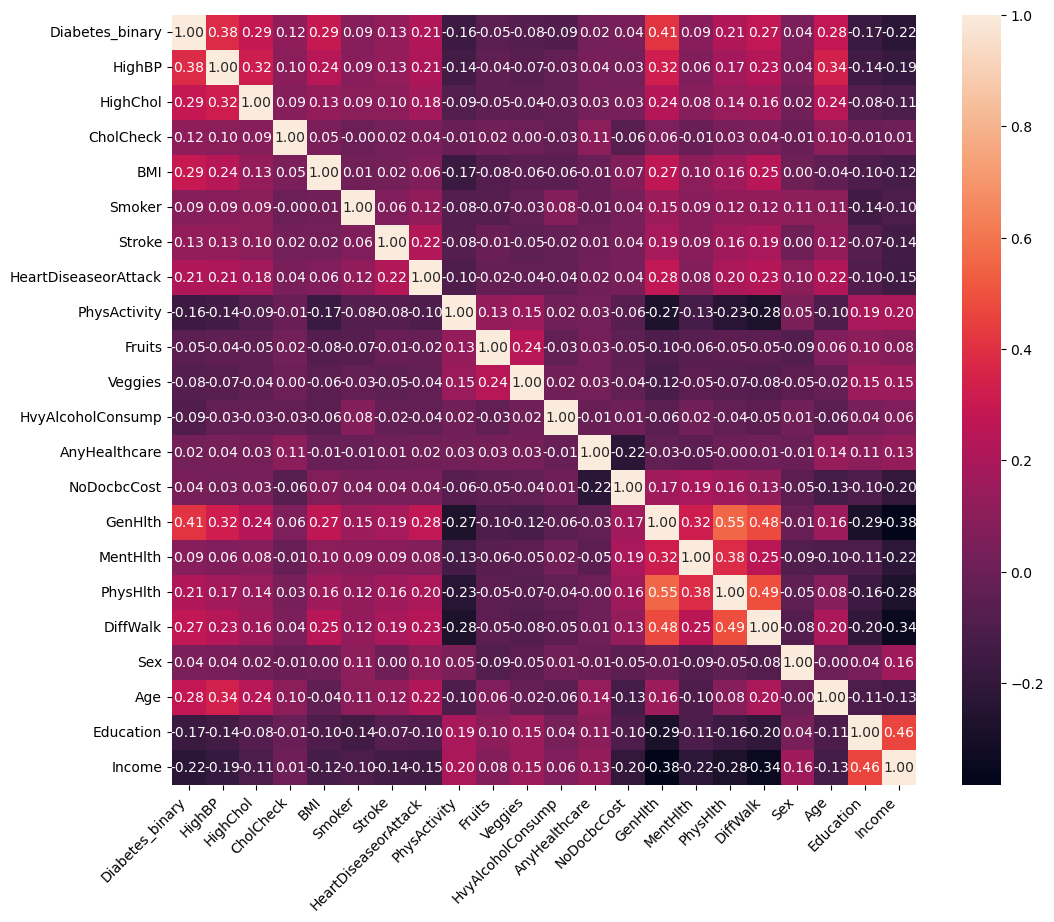

In [24]:
#Create a heatmap to represent the correlation matrix
plt.figure(figsize=(12, 10))
ax = sns.heatmap(diabetes_corr, annot=True, fmt=".2f")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right');

Next, we looked at the distribution of diabetic (1) and non-diabetic (0) observations for different variables

<Axes: xlabel='BMI', ylabel='Count'>

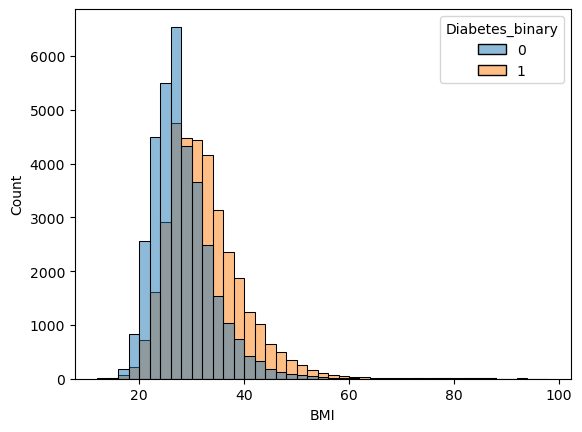

In [25]:
sns.histplot(data=diabetes_df, x="BMI", hue="Diabetes_binary", binwidth=2)

Looking at the distributions in the histogram  above, we can see that individuals with diabetes (Diabetes_binary = 1) have a higher BMI on average.

<Axes: xlabel='count', ylabel='Age'>

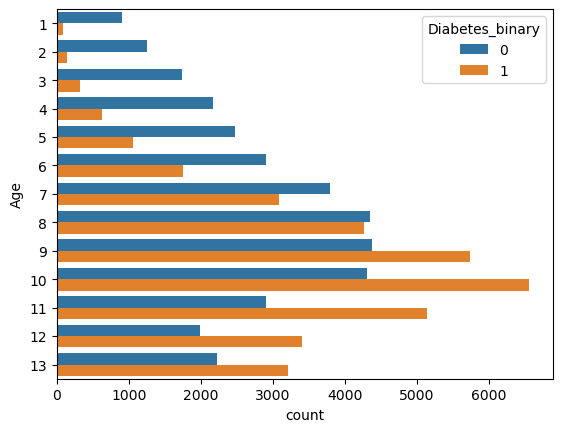

In [26]:
sns.countplot(data=diabetes_df, y="Age", hue="Diabetes_binary")

The graph above shows us that the older individuals in our dataset (age bins 9-13) are more likely to have diabetes.

<Axes: xlabel='count', ylabel='Education'>

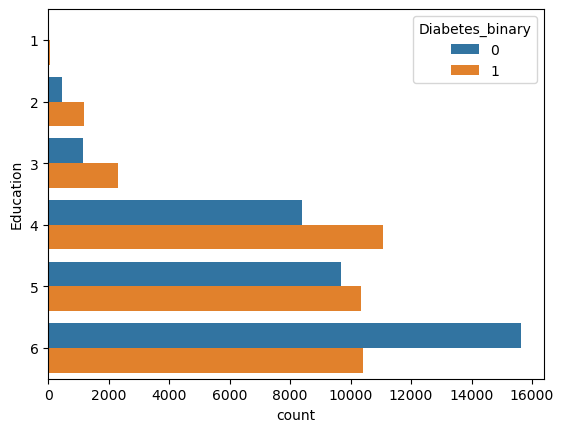

In [27]:
sns.countplot(data=diabetes_df, y="Education", hue="Diabetes_binary")

<Axes: xlabel='count', ylabel='Income'>

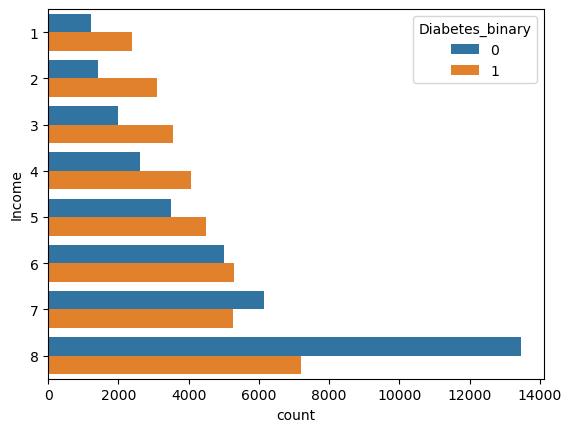

In [28]:
sns.countplot(data=diabetes_df, y="Income", hue="Diabetes_binary")

------------------------------------

## Preprocessing

In [29]:
from sklearn.model_selection import train_test_split

In [30]:
#Separate the target variable from the rest of the dataset
X = diabetes_df.drop(['Diabetes_binary'], axis=1)
y = diabetes_df.Diabetes_binary

In [31]:
#Split dataset into training, validation, and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=5)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.3, random_state=5)

---------------------------------

 ## Random Forest Model

In [32]:
from sklearn import metrics
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

First, I am going to create a Random Forest model using all default parameters. This will serve as a baseline.

Then, we will perform hyperparameter tuning to hopefully find a better Random Forest model.

In [33]:
#Define and fit Random Forest model using default parameters
base_rf = RandomForestClassifier()
base_rf.fit(X_train, y_train)

RandomForestClassifier()

In [34]:
#Make predictions on the train and validation sets
base_rf_train_preds = base_rf.predict(X_train)
base_rf_val_preds = base_rf.predict(X_val)

#Calculate accuracy of training and validation predictions
print("Base Model Training Accuracy: ", round(metrics.accuracy_score(y_train, base_rf_train_preds),4))
print("Base Model Validation Accuracy: ", round(metrics.accuracy_score(y_val, base_rf_val_preds),4))

Base Model Training Accuracy:  0.9964
Base Model Validation Accuracy:  0.7366


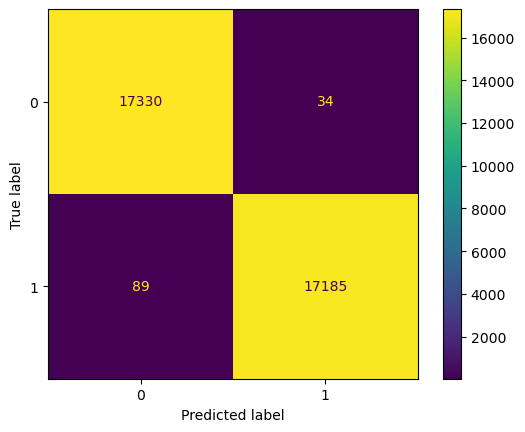

In [35]:
#Create Confusion Matrix for train predictions
metrics.ConfusionMatrixDisplay.from_predictions(y_train, base_rf_train_preds)

In [36]:
#Create classification report to check performance metrics of training predictions
print(metrics.classification_report(y_train, base_rf_train_preds))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00     17364
           1       1.00      0.99      1.00     17274

    accuracy                           1.00     34638
   macro avg       1.00      1.00      1.00     34638
weighted avg       1.00      1.00      1.00     34638



In [37]:
#There are 17364 observations that were true negatives, and 17326 of them were predicted to be negative
print("Training Data Specificity: ", round((17326/17364),4))

Training Data Specificity:  0.9978


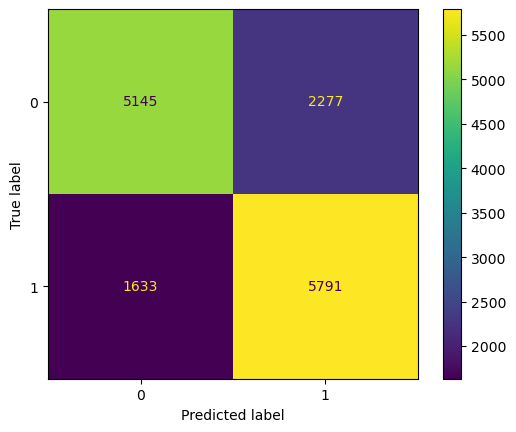

In [38]:
#Create Confusion Matrix for validation predictions
metrics.ConfusionMatrixDisplay.from_predictions(y_val, base_rf_val_preds)

In [39]:
#Create classification report to check performance metrics of validation predictions
print(metrics.classification_report(y_val, base_rf_val_preds))

              precision    recall  f1-score   support

           0       0.76      0.69      0.72      7422
           1       0.72      0.78      0.75      7424

    accuracy                           0.74     14846
   macro avg       0.74      0.74      0.74     14846
weighted avg       0.74      0.74      0.74     14846



In [40]:
#There are 7422 observations that were true negatives, and 5158 of them were predicted to be negative
print("Validation Data Specificity: ", round((5158/7422),4))

Validation Data Specificity:  0.695


There is a large gap between the evaluation metrics of the base random forest model when run against the trainin data compared to the validation data.

This difference indicates that the base model has overfit to the training data.

#### Random Forest Model with Hyperparameter Tuning

In [41]:
#Complete hyper-parameter tuning using GridSearch
rf_params = dict(min_samples_split = [10, 20, 30, 40, 50],
                  max_depth = [1,2,3,4,None])

#Initiate GridSearch object and fit it to training data
rf_gs = GridSearchCV(estimator=base_rf, param_grid=rf_params, scoring='f1', verbose=1, cv=5)
rf_gs.fit(X_train, y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'max_depth': [1, 2, 3, 4, None],
                         'min_samples_split': [10, 20, 30, 40, 50]},
             scoring='f1', verbose=1)

In [42]:
rf_gs.best_params_

{'max_depth': None, 'min_samples_split': 50}

In [43]:
#Define and fit best Random Forest model based on Grid Search results
rf_best = rf_gs.best_estimator_
rf_best.fit(X_train, y_train)

RandomForestClassifier(min_samples_split=50)

In [44]:
#Make predictions on the train and validation sets
rf_best_train_preds = rf_best.predict(X_train)
rf_best_val_preds = rf_best.predict(X_val)

#Calculate accuracy of training and validation predictions
print("Best RF Training Accuracy: ", round(metrics.accuracy_score(y_train, rf_best_train_preds),4))
print("Best RF Validation Accuracy: ", round(metrics.accuracy_score(y_val, rf_best_val_preds),4))


Best RF Training Accuracy:  0.7874
Best RF Validation Accuracy:  0.7493


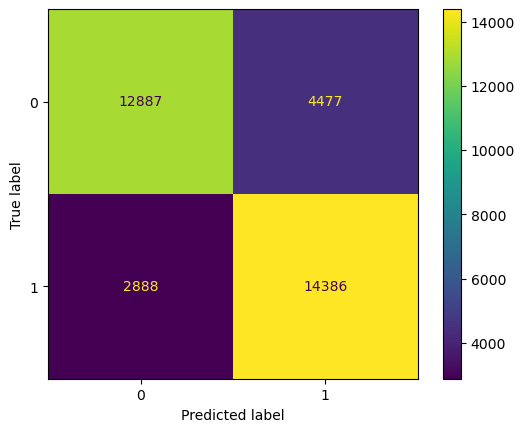

In [45]:
#Create Confusion Matrix for train predictions
metrics.ConfusionMatrixDisplay.from_predictions(y_train, rf_best_train_preds)

In [46]:
#Create classification report to check performance metrics of training predictions
print(metrics.classification_report(y_train, rf_best_train_preds))

              precision    recall  f1-score   support

           0       0.82      0.74      0.78     17364
           1       0.76      0.83      0.80     17274

    accuracy                           0.79     34638
   macro avg       0.79      0.79      0.79     34638
weighted avg       0.79      0.79      0.79     34638



In [47]:
#There are 17364 observations that were true negatives, and 12921 of them were predicted to be negative
print("Training Data Specificity: ", round((12921/17364),4))

Training Data Specificity:  0.7441


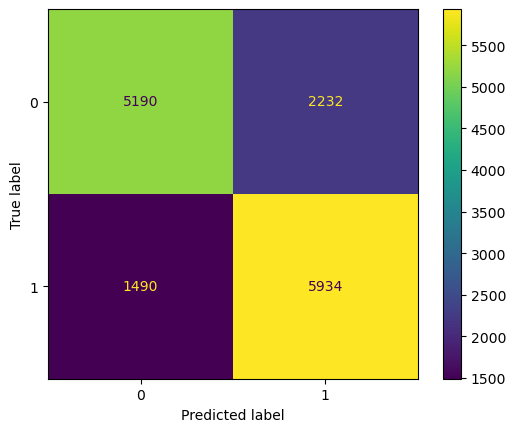

In [48]:
#Create Confusion Matrix for validation predictions
metrics.ConfusionMatrixDisplay.from_predictions(y_val, rf_best_val_preds)

In [49]:
#Create classification report to check performance metrics of validation predictions
print(metrics.classification_report(y_val, rf_best_val_preds))

              precision    recall  f1-score   support

           0       0.78      0.70      0.74      7422
           1       0.73      0.80      0.76      7424

    accuracy                           0.75     14846
   macro avg       0.75      0.75      0.75     14846
weighted avg       0.75      0.75      0.75     14846



In [50]:
#There are 7422 observations that were true negatives, and 5189 of them were predicted to be negative
print("Validation Data Specificity: ", round((5189/7422),4))

Validation Data Specificity:  0.6991


Looking at the performance metrics using the validation data, we were able to improve the Random Forest model's Precision, Recall, F1-Score, Accuracy, and Specificity. 

These results are much more promising. There was a significant decrease in the gap (variance) between the metrics for the training and validation data. Additionally, the model performed better when classifying positive cases.

In [51]:
#Make predictions on the test data
rf_best_test_preds = rf_best.predict(X_test)

#Calculate accuracy of test predictions
print("Best RF Test Accuracy: ", round(metrics.accuracy_score(y_test, rf_best_test_preds),4))

Best RF Test Accuracy:  0.7541


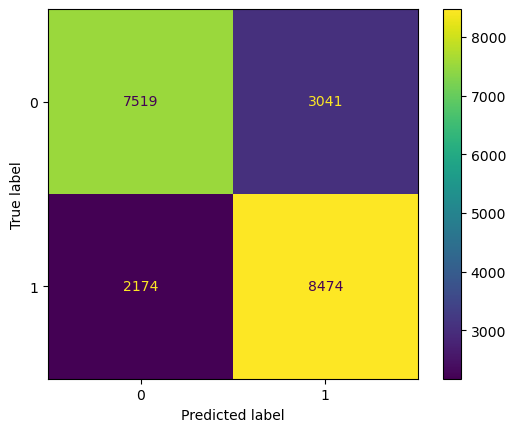

In [52]:
#Create Confusion Matrix for test predictions
metrics.ConfusionMatrixDisplay.from_predictions(y_test, rf_best_test_preds)

In [53]:
#Create classification report to check performance metrics of test predictions
print(metrics.classification_report(y_test, rf_best_test_preds))

              precision    recall  f1-score   support

           0       0.78      0.71      0.74     10560
           1       0.74      0.80      0.76     10648

    accuracy                           0.75     21208
   macro avg       0.76      0.75      0.75     21208
weighted avg       0.76      0.75      0.75     21208



In [54]:
#There are 10560 observations that were true negatives, and 7542 of them were predicted to be negative
print("Test Data Specificity: ", round((7542/10560),4))

Test Data Specificity:  0.7142


-----------------------------------

## Decision Tree

In [55]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV


In [56]:
#Train the decision tree model
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

# Evaluate the decision tree model
y_train_pred = clf.predict(X_train)
y_val_pred = clf.predict(X_val)
y_test_pred = clf.predict(X_test)
train_accuracy = accuracy_score(y_train, y_train_pred)
val_accuracy = accuracy_score(y_val, y_val_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)
confusion_matrix_test = confusion_matrix(y_test, y_test_pred)

print("Decision Tree Model:")
print(f"Training Accuracy: {train_accuracy:.2f}")
print(f"Validation Accuracy: {val_accuracy:.2f}")
print(f"Testing Accuracy: {test_accuracy:.2f}")



Decision Tree Model:
Training Accuracy: 1.00
Validation Accuracy: 0.65
Testing Accuracy: 0.66


In [57]:
# Classification report and confusion matrix for test data
print("Classification Report:")
print(classification_report(y_test, y_test_pred))
print("Confusion Matrix (Testing Data):")
print(confusion_matrix_test)



Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.67      0.66     10560
           1       0.66      0.65      0.66     10648

    accuracy                           0.66     21208
   macro avg       0.66      0.66      0.66     21208
weighted avg       0.66      0.66      0.66     21208

Confusion Matrix (Testing Data):
[[7035 3525]
 [3709 6939]]


 The decision tree model is overfiting. The model has perfect accuracy on training data and a lower accuracy on the validation and testing data.

In [58]:
# Define the parameter grid
param_grid = {
    'criterion': ['gini', 'entropy'],      
    'splitter': ['best', 'random'],        
    'max_depth': [None, 10, 20, 30],       
    'min_samples_split': [2, 10, 20],      
    'min_samples_leaf': [1, 5, 10]         
}

# Create a base model
clf = DecisionTreeClassifier(random_state=42)

# Instantiate the grid search model
grid_search = GridSearchCV(estimator=clf, param_grid=param_grid, 
                           cv=5, n_jobs=-1, verbose=2, scoring='accuracy')

# Fit the grid search to the data
grid_search.fit(X_train, y_train)

# Get the best parameters and the best model
best_params = grid_search.best_params_
best_clf = grid_search.best_estimator_

# Evaluate the tuned decision tree model
y_train_pred_tuned = best_clf.predict(X_train)
y_val_pred_tuned = best_clf.predict(X_val)
y_test_pred_tuned = best_clf.predict(X_test)

#Calculating Accuracy
train_accuracy_tuned = accuracy_score(y_train, y_train_pred_tuned)
val_accuracy_tuned = accuracy_score(y_val, y_val_pred_tuned)
test_accuracy_tuned = accuracy_score(y_test, y_test_pred_tuned)

#Confusion metrices 
confusion_matrix_test_tuned = confusion_matrix(y_test, y_test_pred_tuned)
confusion_matrix_val_tuned = confusion_matrix(y_val, y_val_pred_tuned)

# Extract TN, FP, FN, TP from the confusion matrices
TN_val, FP_val, FN_val, TP_val = confusion_matrix_val_tuned.ravel()
TN_test, FP_test, FN_test, TP_test = confusion_matrix_test_tuned.ravel()

Fitting 5 folds for each of 144 candidates, totalling 720 fits


In [59]:
#Validation data results
print("\nTuned Decision Tree Model:")
print(f"Training Accuracy: {train_accuracy_tuned:.2f}")
print(f"Validation Accuracy: {val_accuracy_tuned:.2f}")
print("Classification Report on validation data:")
print(classification_report(y_val, y_val_pred_tuned))
print("Confusion Matrix (validation Data):")
print(confusion_matrix_val_tuned)
# Compute specificity for validation
specificity_val = TN_val / (TN_val + FP_val)
print(f"Validation Specificity: {specificity_val:.2f}")



Tuned Decision Tree Model:
Training Accuracy: 0.75
Validation Accuracy: 0.73
Classification Report on validation data:
              precision    recall  f1-score   support

           0       0.75      0.69      0.72      7422
           1       0.71      0.77      0.74      7424

    accuracy                           0.73     14846
   macro avg       0.73      0.73      0.73     14846
weighted avg       0.73      0.73      0.73     14846

Confusion Matrix (validation Data):
[[5133 2289]
 [1736 5688]]
Validation Specificity: 0.69


In [60]:
# testing data results
print(f"Testing Accuracy: {test_accuracy_tuned:.2f}")
print("Confusion Matrix (Testing Data):")
print(confusion_matrix_test_tuned)
print("Classification Report on testing data:")
print(classification_report(y_test, y_test_pred_tuned))
# Compute specificity for testing
specificity_test = TN_test / (TN_test + FP_test)
print(f"Testing Specificity: {specificity_test:.2f}")
print(f"\nBest Parameters: {best_params}")

Testing Accuracy: 0.73
Confusion Matrix (Testing Data):
[[7444 3116]
 [2532 8116]]
Classification Report on testing data:
              precision    recall  f1-score   support

           0       0.75      0.70      0.72     10560
           1       0.72      0.76      0.74     10648

    accuracy                           0.73     21208
   macro avg       0.73      0.73      0.73     21208
weighted avg       0.73      0.73      0.73     21208

Testing Specificity: 0.70

Best Parameters: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 10, 'min_samples_split': 2, 'splitter': 'random'}


The hyperparameter-tuned Decision Tree model has improved accuracy on testing and validation data and reduced the overfiting on training data. the tuned model is more balanced, robust and generalizable Decision Tree model

----------------------------------------

# Logistic Regression

In [61]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [62]:
#initializing the logistic regression model
logreg = LogisticRegression(max_iter=1000)

#training the model
logreg.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [63]:
#predicting on the validation set
y_pred_val = logreg.predict(X_val)

#calculating evaluation metrics
accuracy = accuracy_score(y_val, y_pred_val)
precision = precision_score(y_val, y_pred_val)
recall = recall_score(y_val, y_pred_val)
f1 = f1_score(y_val, y_pred_val)

print(f'Accuracy: {accuracy}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1 Score: {f1}')

Accuracy: 0.7455206789707666
Precision: 0.7370611183355007
Recall: 0.7634698275862069
F1 Score: 0.7500330819108112


In comparison with unbalanced dataset the results show the importance of balancing classes in datasets where there is a significant class imbalance.
The balanced dataset has led to:
A decrease in accuracy due to the removal of bias towards the majority class.
A significant increase in recall, demonstrating better identification of positive cases.
An improved F1 score, indicating a more balanced and effective model performance.

To optimize the model's performance and ensure its reliability, applying hyper parameter tuning combined with cross-validation here.


In [64]:
from sklearn.model_selection import GridSearchCV

#define the model and parameters
model = LogisticRegression(max_iter=1000)
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],  #regularization values
    'solver': ['liblinear', 'lbfgs']  #solvers
}

#creating GridSearchCV object
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5,
                           scoring='accuracy', verbose=1, n_jobs=-1)

In [65]:
#fitting GridSearchCV to the training data
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000), n_jobs=-1,
             param_grid={'C': [0.001, 0.01, 0.1, 1, 10, 100],
                         'solver': ['liblinear', 'lbfgs']},
             scoring='accuracy', verbose=1)

In [66]:
#the best parameters and the best score
print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validated score: ", grid_search.best_score_)

#examine all results
results = pd.DataFrame(grid_search.cv_results_)
print(results[['param_C', 'param_solver', 'mean_test_score']])

Best parameters found:  {'C': 1, 'solver': 'liblinear'}
Best cross-validated score:  0.7465500038174417
   param_C param_solver  mean_test_score
0    0.001    liblinear         0.726832
1    0.001        lbfgs         0.742537
2     0.01    liblinear         0.738755
3     0.01        lbfgs         0.746492
4      0.1    liblinear         0.745222
5      0.1        lbfgs         0.746030
6        1    liblinear         0.746550
7        1        lbfgs         0.745973
8       10    liblinear         0.746088
9       10        lbfgs         0.746001
10     100    liblinear         0.745886
11     100        lbfgs         0.746146


Evaluating the best models performace on validation set


In [67]:
#best estimator to make predictions
y_pred_val = grid_search.best_estimator_.predict(X_val)

#evaluating these predictions
print("Validation Accuracy: ", accuracy_score(y_val, y_pred_val))
print("Validation Precision: ", precision_score(y_val, y_pred_val))
print("Validation Recall: ", recall_score(y_val, y_pred_val))
print("Validation F1 Score: ", f1_score(y_val, y_pred_val))

Validation Accuracy:  0.7456553953926983
Validation Precision:  0.7368216047779798
Validation Recall:  0.7644127155172413
Validation F1 Score:  0.7503636123231521


Testing the Model on the **Test Set**


In [68]:
#using the best estimator to make predictions on the test set
y_pred_test = grid_search.best_estimator_.predict(X_test)

#evaluating the predictions
test_accuracy = accuracy_score(y_test, y_pred_test)
test_precision = precision_score(y_test, y_pred_test)
test_recall = recall_score(y_test, y_pred_test)
test_f1 = f1_score(y_test, y_pred_test)

print(f"Test Accuracy: {test_accuracy}")
print(f"Test Precision: {test_precision}")
print(f"Test Recall: {test_recall}")
print(f"Test F1 Score: {test_f1}")

Test Accuracy: 0.7531120331950207
Test Precision: 0.7454199165608562
Test Recall: 0.7718820435762584
Test F1 Score: 0.7584202270000924


The logistic regression model, tuned using GridSearchCV on a balanced dataset, demonstrated robust performance on the test set. The model achieved an **accuracy of 75.30%**, a **precision of 74.53%**, a **recall of 77.18%**, and an **F1 score of 75.83%**. These metrics indicate a strong balance between precision and recall, highlighting the model's capability to effectively identify true cases of diabetes while maintaining a reasonable rate of correct predictions. This performance suggests that the model is well\-suited for potential clinical application, where accurately detecting diabetes is crucial. The model's high recall rate is particularly valuable in a medical context, ensuring that fewer actual cases of diabetes go undiagnosed.


---------------------------------

# Boosting Model



In [69]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [70]:
#features and target variable
X = diabetes_df.drop(columns=['Diabetes_binary'])
y = diabetes_df['Diabetes_binary']
# Split the data into training, validation and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=42)

In [71]:
# Initialize the Gradient Boosting Classifier
gb_clf = GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42)

In [72]:
# Fit the model on the training data
gb_clf.fit(X_train, y_train)

# predict on the training data
y_pred_train = gb_clf.predict(X_train)

# accuracy on the training data
train_accuracy = accuracy_score(y_train, y_pred_train)
print('Training Accuracy:', train_accuracy)

Training Accuracy: 0.7582166265855613


In [73]:
# Predict the target on the validation data
y_val_pred = gb_clf.predict(X_val)

# Calculate the accuracy of the model on the validation data
accuracy = accuracy_score(y_val, y_val_pred)
print('Validation Accuracy:', accuracy)

Validation Accuracy: 0.7487092439352147


Does not appear to be overfitting as was the case with the two previous models, the Decision Tree and the Random Forest model.


In [74]:
# Confusion matrix
conf_matrix = confusion_matrix(y_val, y_val_pred)
print('Confusion Matrix:')
print(conf_matrix)

Confusion Matrix:
[[5019 2041]
 [1512 5567]]


In [75]:
# Classification report
class_report = classification_report(y_val, y_val_pred)
print('Classification Report:')
print(class_report)

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.71      0.74      7060
           1       0.73      0.79      0.76      7079

    accuracy                           0.75     14139
   macro avg       0.75      0.75      0.75     14139
weighted avg       0.75      0.75      0.75     14139



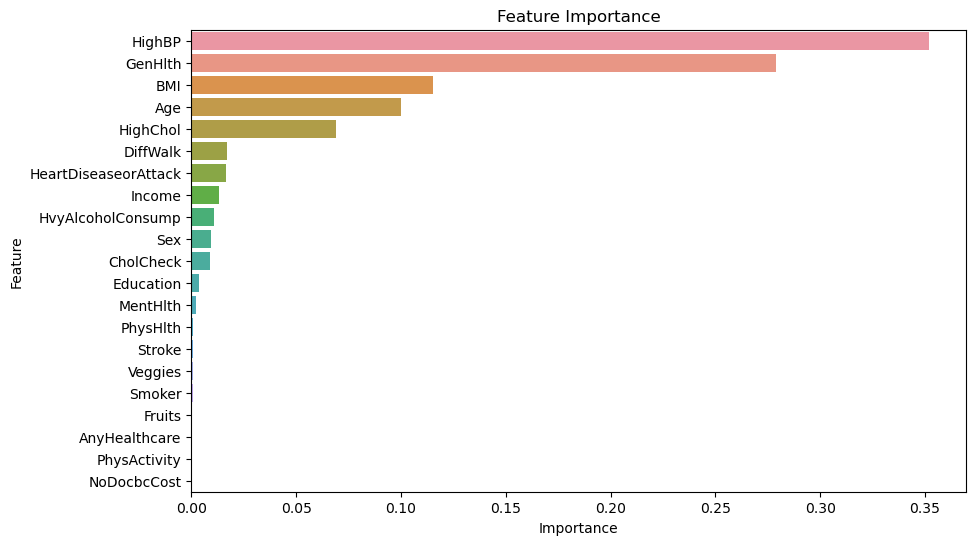

In [76]:
# Feature importance
feature_importance = gb_clf.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importance})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)\

# Plot the feature importance
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df, x='Importance', y='Feature')
plt.title('Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [77]:
# Define the hyperparameters to tune
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 1]
}

In [78]:
# Initialize the Gradient Boosting Classifier
gb_clf = GradientBoostingClassifier(random_state=42)

# Initialize the Grid Search Cross Validation
grid_search = GridSearchCV(estimator=gb_clf, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)

# Fit the model on the training data
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 27 candidates, totalling 81 fits


GridSearchCV(cv=3, estimator=GradientBoostingClassifier(random_state=42),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1, 1],
                         'max_depth': [3, 5, 7],
                         'n_estimators': [50, 100, 200]},
             verbose=2)

In [79]:
# Get the best hyperparameters
best_params = grid_search.best_params_

# Print the best hyperparameters
print('Best Hyperparameters:', best_params)

Best Hyperparameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}


In [80]:
# Predict the target on the validation data using the best model
best_gb_clf = grid_search.best_estimator_
y_val_pred = best_gb_clf.predict(X_val)

In [81]:
# Classification report
class_report = classification_report(y_val, y_val_pred)
print('Classification Report:')
print(class_report)

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.71      0.74      7060
           1       0.73      0.79      0.76      7079

    accuracy                           0.75     14139
   macro avg       0.75      0.75      0.75     14139
weighted avg       0.75      0.75      0.75     14139



In [82]:
# Predict the target on the test data using the best model
y_test_pred = best_gb_clf.predict(X_test)

# Calculate the accuracy of the model on the test data
accuracy = accuracy_score(y_test, y_test_pred)
print('Test Accuracy:', accuracy)

Test Accuracy: 0.7553575217483556


In [83]:
# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_test_pred)
print('Confusion Matrix:')
print(conf_matrix)

Confusion Matrix:
[[5080 2010]
 [1449 5600]]


In [84]:
# classification report
class_report = classification_report(y_test, y_test_pred)
print('Classification Report:')
print(class_report)

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.72      0.75      7090
           1       0.74      0.79      0.76      7049

    accuracy                           0.76     14139
   macro avg       0.76      0.76      0.76     14139
weighted avg       0.76      0.76      0.76     14139



Not much improvement using hyperparameter tuning as only had slight increase in accuracy with no notable change sin other metrics.


------------------------------

# NeuralNetwork

In [85]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import Binarizer
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

In [86]:
model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(35, activation='relu'),
    Dense(35, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [87]:
history = model.fit(X_train, y_train, epochs=20, verbose=1, validation_data=(X_val, y_val))

pred_train = model.predict(X_train)
pred_val = model.predict(X_val)

Epoch 1/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 2s 891us/step - accuracy: 0.6982 - loss: 0.5773 - val_accuracy: 0.7301 - val_loss: 0.5411
Epoch 2/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 1s 781us/step - accuracy: 0.7353 - loss: 0.5289 - val_accuracy: 0.7229 - val_loss: 0.5528
Epoch 3/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 1s 776us/step - accuracy: 0.7398 - loss: 0.5253 - val_accuracy: 0.7361 - val_loss: 0.5250
Epoch 4/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 1s 772us/step - accuracy: 0.7434 - loss: 0.5176 - val_accuracy: 0.7393 - val_loss: 0.5264
Epoch 5/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 1s 869us/step - accuracy: 0.7423 - loss: 0.5187 - val_accuracy: 0.7392 - val_loss: 0.5232
Epoch 6/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 1s 788us/step - accuracy: 0.7441 - loss: 0.5168 - val_accuracy: 0.7415 - val_loss: 0.5200
Epoch 7/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 1s 776us/step - accuracy: 0.7458 - loss: 0.5134 - val_accuracy: 0.7440 - val_loss: 0.5173
Epoch 8/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 1s 776us/step - accuracy: 0.7489 -

In [88]:
pred_train.mean()

0.487872

Classification Report 
               precision    recall  f1-score   support

           0       0.76      0.72      0.74      7060
           1       0.73      0.77      0.75      7079

    accuracy                           0.75     14139
   macro avg       0.75      0.75      0.74     14139
weighted avg       0.75      0.75      0.74     14139



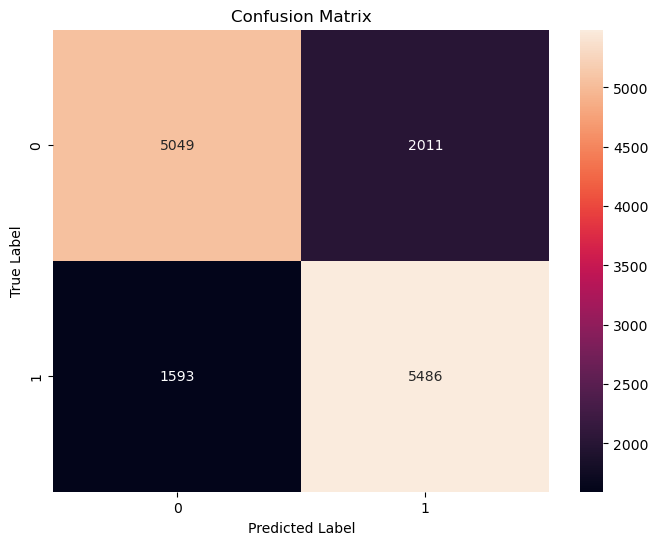

In [89]:
pred_train_labels = (pred_train > 0.5).astype(int)
pred_val_labels = (pred_val > 0.5).astype(int)

train_accuracy = metrics.accuracy_score(y_train, pred_train_labels)
val_accuracy = metrics.accuracy_score(y_val, pred_val_labels)

train_f1_score = metrics.f1_score(y_train, pred_train_labels, average='weighted')
val_f1_score = metrics.f1_score(y_val, pred_val_labels, average='weighted')

print("Classification Report \n", metrics.classification_report(y_val, pred_val_labels))
conf_mat = confusion_matrix(y_val, pred_val_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_mat, annot=True,fmt='g')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [90]:
print('Validation Accuracy', val_accuracy)
print('Train Accuracy', train_accuracy)

Validation Accuracy 0.7451021995897871
Train Accuracy 0.7531239685009666


In [91]:
print('Train F1:', train_f1_score)
print('Validation F1', val_f1_score)

Train F1: 0.7528831793441456
Validation F1 0.7448690678075552


A balance in bias-variance was obtained using 2 hidden layers with 20 nodes each training on 25 epochs.

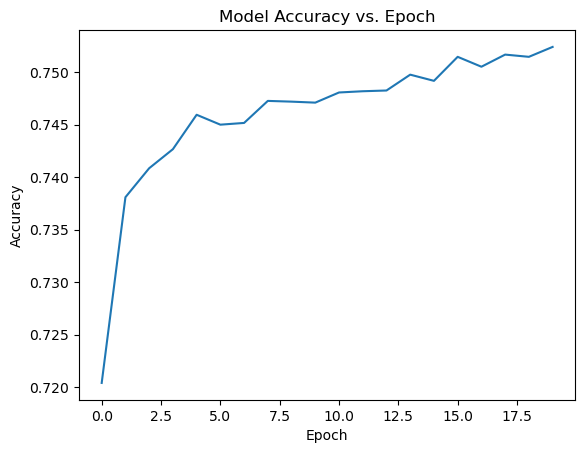

In [92]:
plt.plot(history.history['accuracy'])
plt.title('Model Accuracy vs. Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

442/442 ━━━━━━━━━━━━━━━━━━━━ 0s 471us/step
Classification Report 
               precision    recall  f1-score   support

           0       0.77      0.72      0.74      7090
           1       0.73      0.78      0.76      7049

    accuracy                           0.75     14139
   macro avg       0.75      0.75      0.75     14139
weighted avg       0.75      0.75      0.75     14139



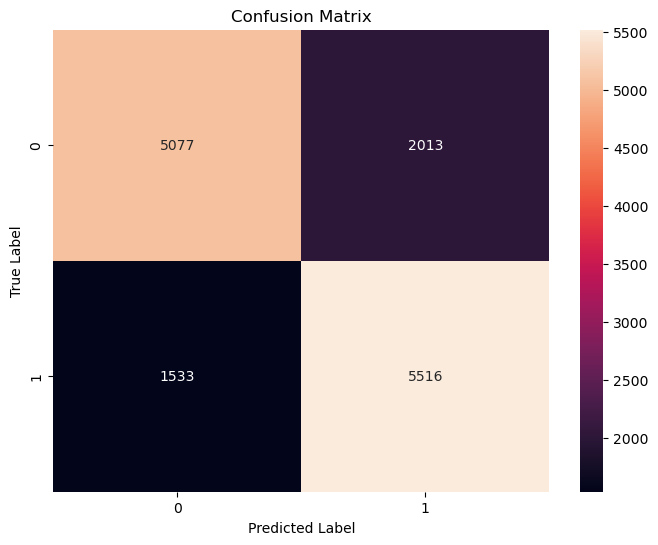

In [93]:
pred_test = model.predict(X_test)
pred_test_labels = (pred_test > 0.5).astype(int)

test_accuracy = metrics.accuracy_score(y_test, pred_test_labels)

test_f1_score = metrics.f1_score(y_test, pred_test_labels, average='weighted')

print("Classification Report \n", metrics.classification_report(y_test, pred_test_labels))
conf_mat = confusion_matrix(y_test, pred_test_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_mat, annot=True,fmt='g')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [94]:
report = classification_report(y_test, pred_test_labels, output_dict=True)
test_precision = report['weighted avg']['precision']
test_recall = report['weighted avg']['recall']

In [95]:
performance = []

In [96]:
neuralnet_performance = {
    'Model': 'NeuralNet',
    'Accuracy': test_accuracy,
    'F1-score': test_f1_score,
    'Weighted avg Recall': test_recall,
    'Weighted avg Precision': test_precision,
    'Total number of epochs': 25,
    'Number of total parameters': model.count_params(),
    'Number of hidden layers': 2,
    'Number of neurons in each hidden layer': '20-20',
}
performance.append(neuralnet_performance)
performance_df = pd.DataFrame(performance)
performance_df

,Model,Accuracy,F1-score,Weighted avg Recall,Weighted avg Precision,Total number of epochs,Number of total parameters,Number of hidden layers,Number of neurons in each hidden layer
0,NeuralNet,0.749204,0.74894,0.749204,0.750408,25,2066,2,20-20


-----------------------------------

## Results

In [97]:
#Summarize Model Results on Validation Data
print("Evaluation Metrics (Weighted Average) for Our Models Predicting Validation Data")
model_val_results = pd.DataFrame([["Random Forest", 0.75, 0.75, 0.75, 0.75],
                              ["Decision Tree", 0.73, 0.73, 0.73, 0.73],
                             ["Logistic Regression", 0.75, 0.74, 0.76, 0.75],
                             ["Gradient Boost", 0.75, 0.75, 0.75, 0.75],
                             ["Neural Network", 0.75, 0.75, 0.75, 0.75]],
                       columns=["Model","Accuracy","Precision","Recall","F1-Score"])
model_val_results

Evaluation Metrics (Weighted Average) for Our Models Predicting Validation Data


,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.75,0.75,0.75,0.75
1,Decision Tree,0.73,0.73,0.73,0.73
2,Logistic Regression,0.75,0.74,0.76,0.75
3,Gradient Boost,0.75,0.75,0.75,0.75
4,Neural Network,0.75,0.75,0.75,0.75


In [98]:
#Summarize Model Results on Test Data
print("Evaluation Metrics (Weighted Average) for Our Models Predicting Test Data")
model_test_results = pd.DataFrame([["Random Forest", 0.75, 0.76, 0.75, 0.75],
                              ["Decision Tree", 0.73, 0.73, 0.73, 0.73],
                             ["Logistic Regression", 0.75, 0.75, 0.77, 0.76],
                             ["Gradient Boost", 0.76, 0.76, 0.76, 0.76],
                             ["Neural Network", 0.75, 0.76, 0.75, 0.75]],
                       columns=["Model","Accuracy","Precision","Recall","F1-Score"])
model_test_results

Evaluation Metrics (Weighted Average) for Our Models Predicting Test Data


,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.75,0.76,0.75,0.75
1,Decision Tree,0.73,0.73,0.73,0.73
2,Logistic Regression,0.75,0.75,0.77,0.76
3,Gradient Boost,0.76,0.76,0.76,0.76
4,Neural Network,0.75,0.76,0.75,0.75


----------------------------------

## Conclusion

Based on the evaluation metrics we used, all five of our tuned models performed well when predicting the validation and test data. For the most part, all of the metrics were around 0.75 for all models. These results are promising, and we believe any of these ML models would be good candidates to be used to identify individuals who are already prediabetic/diabetic or at risk of becoming diabetic.

If we had to choose one model from this group, we would choose the Gradient Boost model as it had sligthly better metrics on average.